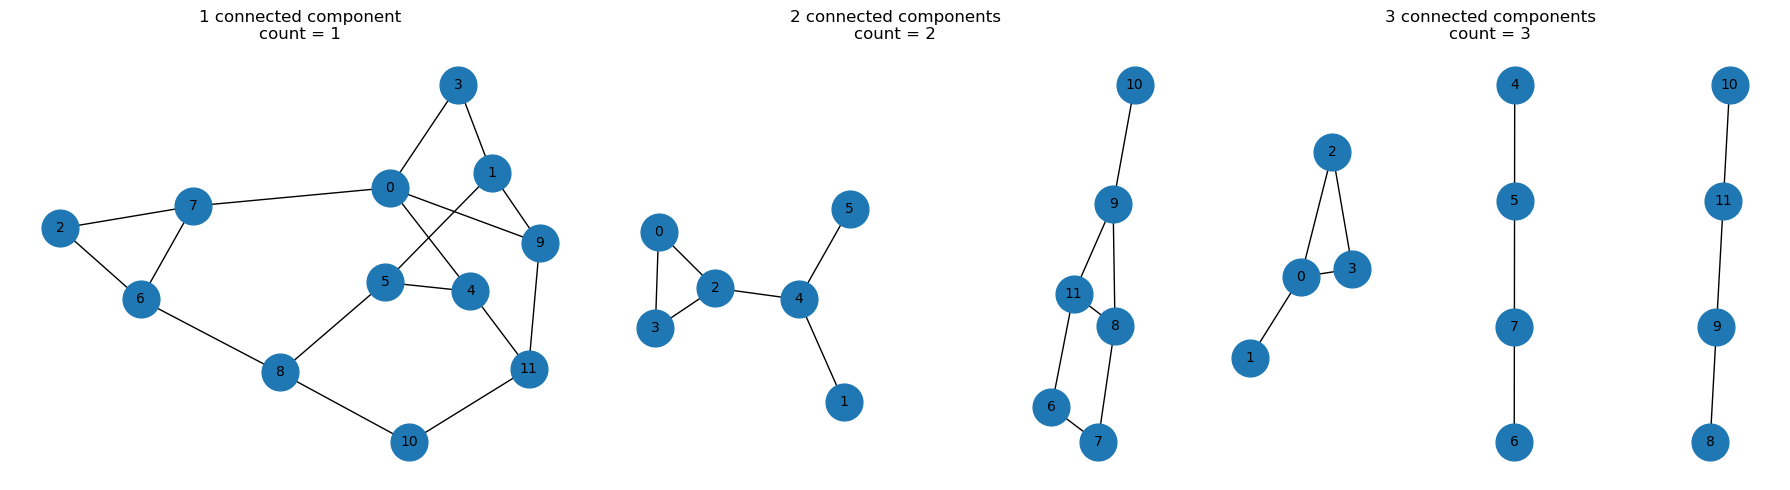

G1 connected components: 1
G2 connected components: 2
G3 connected components: 3


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# =========================================
# Setting
# =========================================
SEED = 42
random.seed(SEED)

# =========================================
# Helper: make one connected random graph
# =========================================
def make_connected_random_graph(n, p, seed=None):
    """
    n nodes, edge probability p
    Retry until the graph becomes connected
    """
    rng = random.Random(seed)
    while True:
        s = rng.randint(0, 10**9)
        G = nx.erdos_renyi_graph(n=n, p=p, seed=s)
        if nx.is_connected(G):
            return G

# =========================================
# Helper: combine multiple connected graphs
# =========================================
def make_graph_with_k_components(component_sizes, p=0.4, seed=42):
    """
    Create a graph with exactly len(component_sizes) connected components.
    Each component is internally connected, and there are no edges between components.
    """
    graphs = []
    rng = random.Random(seed)

    for i, size in enumerate(component_sizes):
        sub_seed = rng.randint(0, 10**9)

        if size == 1:
            G_sub = nx.empty_graph(1)
        else:
            G_sub = make_connected_random_graph(size, p, seed=sub_seed)

        graphs.append(G_sub)

    G = nx.disjoint_union_all(graphs)
    return G

# =========================================
# Create graphs
# =========================================
# 1 connected component
G1 = make_graph_with_k_components([12], p=0.25, seed=1)

# 2 connected components
G2 = make_graph_with_k_components([6, 6], p=0.35, seed=2)

# 3 connected components
G3 = make_graph_with_k_components([4, 4, 4], p=0.45, seed=3)

# =========================================
# Draw function
# =========================================
def draw_graph_with_components(ax, G, title, seed=42):
    components = list(nx.connected_components(G))
    subgraphs = [G.subgraph(c).copy() for c in components]

    # Place each component apart from the others
    pos = {}
    x_shift = 0.0

    for i, sg in enumerate(subgraphs):
        local_pos = nx.spring_layout(sg, seed=seed + i)

        # shift each component to the right
        for node, (x, y) in local_pos.items():
            pos[node] = (x + x_shift, y)

        x_shift += 3.5

    nx.draw(
        G,
        pos,
        ax=ax,
        with_labels=True,
        node_size=700,
        font_size=10
    )

    ax.set_title(title)
    ax.axis("off")

# =========================================
# Plot
# =========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

draw_graph_with_components(
    axes[0],
    G1,
    f"1 connected component\ncount = {nx.number_connected_components(G1)}",
    seed=10
)

draw_graph_with_components(
    axes[1],
    G2,
    f"2 connected components\ncount = {nx.number_connected_components(G2)}",
    seed=20
)

draw_graph_with_components(
    axes[2],
    G3,
    f"3 connected components\ncount = {nx.number_connected_components(G3)}",
    seed=30
)

plt.tight_layout()
plt.show()

# =========================================
# Check
# =========================================
print("G1 connected components:", nx.number_connected_components(G1))
print("G2 connected components:", nx.number_connected_components(G2))
print("G3 connected components:", nx.number_connected_components(G3))